In [2]:
import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import LogLocator, ScalarFormatter, LogFormatter
import seaborn as sns

palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = df[(df['dist']<1.5) & (df['Av']<0.5)]

In [10]:
def calcula_fracoes(data, mask_mass, mask_comp_mass,):
    
    N_stars = mask_mass.sum() + mask_comp_mass.sum()
    N_prim = ((mask_mass) & (data['q'] > 0)).sum()
    F_prim = N_prim / N_stars
    
    N_comp = (mask_comp_mass & (data['q'] > 0)).sum()
    F_comp = N_comp / N_stars 
    
    
    N_BS = N_prim + N_comp
    F_BS = N_BS / N_stars

    return F_prim, F_comp, F_BS, N_prim, N_comp, N_BS


def bootstrap_samples(data, n_boot=1000, random_state=None):
    aux=data.copy(deep=True)
    
    rng = np.random.default_rng(random_state)
    idx = np.arange(len(aux))
    samples_bootstrap = []
    for _ in range(n_boot):
        resample_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = aux.iloc[resample_idx]        
        samples_bootstrap.append(sample)
    return samples_bootstrap


def realiza_loop(aux, min_mass, max_mass, dm=0.05):
        
        m_min = min_mass
        m_max = m_min+dm
        
        mass_bins = []
        F_prim_arr = []
        F_comp_arr = []
        F_BS_arr = []
        
        F_prim_p16, F_prim_p84 = [], []
        F_comp_p16, F_comp_p84 = [], []
        F_BS_p16,   F_BS_p84   = [], []
        
            
        
        while m_min <= max_mass:
            
            if m_max> max_mass:
                break
                
            if m_min < np.log10(4):
                dm = 0.05
            else:
                dm = np.log10(1 + 1 / (10**m_min))
                
            mask_mass = (aux['mass'] >=m_min) & (aux['mass'] <m_max)
            mask_comp_mass = (aux['comp_mass'] >=m_min) & (aux['comp_mass'] < m_max)
            total_stars = mask_mass.sum() + mask_comp_mass.sum()
            
            if total_stars>=1000:
                
                F_prim, F_comp, F_BS, N_prim, N_comp, N_BS = calcula_fracoes(aux, mask_mass, mask_comp_mass)
                masses = np.concatenate([aux[mask_mass]['mass'].to_numpy(), aux[mask_comp_mass]['comp_mass'].to_numpy()])
                median_mass = np.median(masses)
                
                mass_bins.append(median_mass) 
                F_prim_arr.append(F_prim) 
                F_comp_arr.append(F_comp) 
                F_BS_arr.append(F_BS)

                
        
                m_min = m_min + dm 
            m_max = m_max + dm

        return (np.array(mass_bins),np.array(F_prim_arr),np.array(F_comp_arr),np.array(F_BS_arr))

    
            



In [18]:
results =[[], []]
p16 = [[], []]
p84 = [[], []]

for i in range(0, len(results)):
    if i==0:
        aux = data[['mass', 'comp_mass','q']].copy(deep=True)
    else:
        aux = data[(data['dist']<1.5) & (data['Av']<0.5)][['mass', 'comp_mass','q']].copy(deep=True)

    aux['mass'] = np.log10(aux['mass'])
    aux['comp_mass'] = np.log10(aux['comp_mass'])
    min_mass = min(aux['mass'].min(), aux[aux['comp_mass']>0]['comp_mass'].min())
    max_mass = max(aux['mass'].max(), aux[aux['comp_mass']>0]['comp_mass'].max())

    mass_bins, F_prim_arr, F_comp_arr, F_BS_arr, *_ = realiza_loop(aux,min_mass, max_mass, dm=0.05)

    results[i].append(mass_bins) 
    results[i].append(F_prim_arr) 
    results[i].append(F_comp_arr) 
    results[i].append(F_BS_arr) 

    boot_samples = bootstrap_samples(aux, n_boot=100, random_state=1)

    Fp_boot, Fc_boot, Fbs_boot = [], [], []
    
    for boot_sample in boot_samples:
        mb, Fp, Fc, Fbs = realiza_loop(boot_sample,min_mass, max_mass, dm=0.05)

        Fp_i  = np.interp(mass_bins, mb, Fp, left=np.nan, right=np.nan)
        Fc_i  = np.interp(mass_bins, mb, Fc, left=np.nan, right=np.nan)
        Fbs_i = np.interp(mass_bins, mb, Fbs, left=np.nan, right=np.nan)
    
        Fp_boot.append(Fp_i)
        Fc_boot.append(Fc_i)
        Fbs_boot.append(Fbs_i)

    Fp_boot = np.array(Fp_boot)
    Fc_boot = np.array(Fc_boot)
    Fbs_boot = np.array(Fbs_boot)

    Fp_p16 = np.nanpercentile(Fp_boot, 16, axis=0)
    Fp_p50 = np.nanpercentile(Fp_boot, 50, axis=0)
    Fp_p84 = np.nanpercentile(Fp_boot, 84, axis=0)

    Fc_p16 = np.nanpercentile(Fc_boot, 16, axis=0)
    Fc_p50 = np.nanpercentile(Fc_boot, 50, axis=0)
    Fc_p84 = np.nanpercentile(Fc_boot, 84, axis=0)

    Fbs_p16 = np.nanpercentile(Fbs_boot, 16, axis=0)
    Fbs_p50 = np.nanpercentile(Fbs_boot, 50, axis=0)
    Fbs_p84 = np.nanpercentile(Fbs_boot, 84, axis=0)

    p16[i].append(Fp_p16)
    p16[i].append(Fc_p16)
    p16[i].append(Fbs_p16)
    
    p84[i].append(Fp_p84)
    p84[i].append(Fc_p84)
    p84[i].append(Fbs_p84)

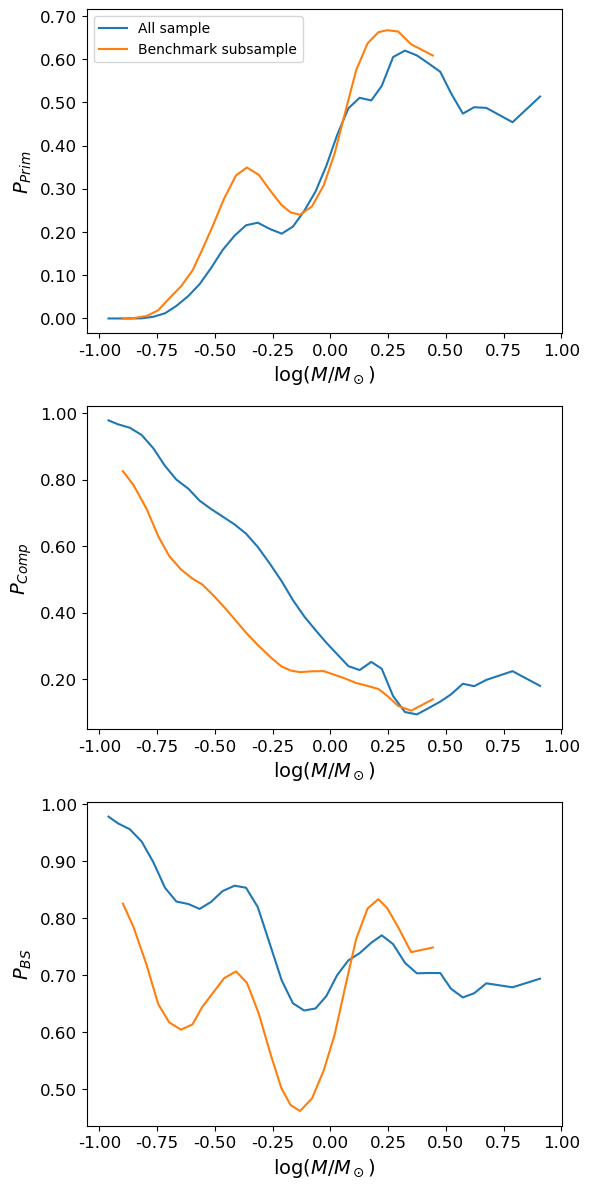

In [17]:
fig, axs = plt.subplots(3,1, figsize=(6,12))


for i in range(1, len(results[0])):
    j =i-1
   
    axs[j].plot(results[0][0],  results[0][i],  label='All sample')
    axs[j].fill_between(results[0][0], p16[0][j], p84[0][j], alpha=0.3)
    

    axs[j].plot(results[1][0],  results[1][i], label = 'Benchmark subsample')
    axs[j].fill_between(results[1][0], p16[1][j], p84[1][j], alpha=0.3)
                    

axs[0].set_ylabel(r'$P_{Prim}$', fontdict=font)
axs[1].set_ylabel(r'$P_{Comp}$', fontdict=font)
axs[2].set_ylabel(r'$P_{BS}$', fontdict=font)
for ax in axs:
    ax.set_xlabel(r'$\log(M/M_\odot)$', fontdict=font)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
axs[0].legend()
#plt.savefig('Figures/dist_fb_por_massa.png', dpi=300)
plt.show() 

In [14]:
results


[[array([0.11963416, 0.17022947, 0.21827431, 0.26810802, 0.31839036,
         0.36901748, 0.41877174, 0.47004623, 0.51908632, 0.56935644,
         0.63714118, 0.69192118, 0.80148907, 0.9184892 ]),
  array([0.51801827, 0.50471919, 0.5154656 , 0.61271814, 0.61680151,
         0.61339846, 0.59276438, 0.58755943, 0.5133515 , 0.48575712,
         0.47897623, 0.47368421, 0.43686636, 0.52077562]),
  array([0.21831905, 0.24774081, 0.25960989, 0.14726273, 0.10569805,
         0.08816004, 0.10791589, 0.12440571, 0.15095368, 0.1844078 ,
         0.18586228, 0.21376518, 0.22857143, 0.17266851]),
  array([0.73633732, 0.75246   , 0.77507549, 0.75998087, 0.72249957,
         0.7015585 , 0.70068027, 0.71196513, 0.66430518, 0.67016492,
         0.66483851, 0.68744939, 0.66543779, 0.69344414])],
 [array([0.11898478, 0.19195227, 0.23549758, 0.29830976, 0.38402126,
         0.46230857]),
  array([0.61101836, 0.65534521, 0.66905444, 0.67129228, 0.62068966,
         0.61438561]),
  array([0.16277129, 0.1998

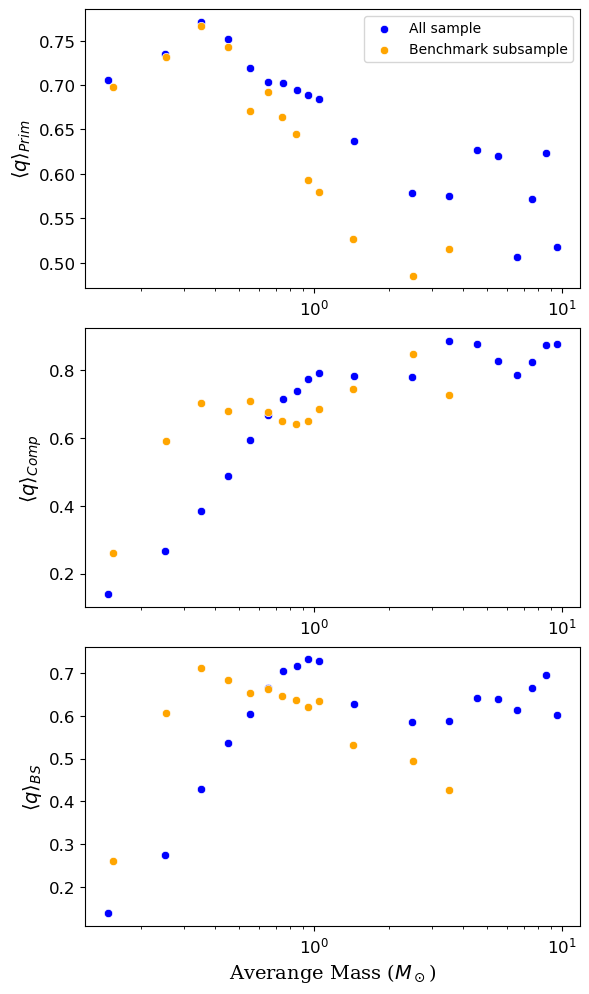

In [92]:
fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

for sample in samples:
    if sample == 'benchmark':
        data = results_benchmark
        color = 'orange'
        label = 'Benchmark subsample'
        
    else:
        data = results_all
        color = 'b'
        label = 'All sample'

    sns.scatterplot(data= data, x='mean_mass', y='q_prim', color=color, label=label, legend=True, ax=axs[0])
    sns.scatterplot(data= data, x='mean_mass', y='q_comp', color=color, legend=False, ax=axs[1])
    sns.scatterplot(data= data, x='mean_mass', y='q_BS', color=color, legend=False, ax=axs[2])

    #err_y = np.sqrt(data.n_stars) / data.n_stars

    #axs[0].errorbar(data.mean_mass, data.P_prim, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    #axs[1].errorbar(data.mean_mass, data.P_comp, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    #axs[2].errorbar(data.mean_mass, data.P_BS, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)

    # Rótulos dos eixos
    axs[0].set_ylabel(r'$\langle q \rangle_{Prim}$', fontdict=font)
    axs[1].set_ylabel(r'$\langle q \rangle_{Comp}$', fontdict=font)
    axs[2].set_ylabel(r'$\langle q \rangle_{BS}$', fontdict=font)
    axs[2].set_xlabel(r'Averange Mass ($M_\odot$)', fontdict=font)

for ax in axs:
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)

plt.tight_layout()
plt.xscale('log')
plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show()


# Low-mass

In [119]:
results_all[results_all.max_mass<=1][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
P_prim,9.0,0.20,0.11,0.00,0.17,0.21,0.25,0.35
P_comp,9.0,0.57,0.21,0.32,0.40,0.55,0.71,0.93
P_BS,9.0,0.77,0.12,0.64,0.66,0.77,0.88,0.93
q_prim,9.0,0.72,0.03,0.69,0.70,0.71,0.74,0.77
q_comp,9.0,0.53,0.23,0.14,0.38,0.59,0.71,0.77
q_BS,9.0,0.53,0.21,0.14,0.43,0.60,0.70,0.73


In [121]:
results_all[results_all.max_mass<=1][['mean_mass','P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].corr()

,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,0.932166,-0.990016,-0.923644,-0.610345,0.973524,0.945876
P_prim,0.932166,1.000000,-0.931799,-0.755917,-0.314866,0.938737,0.946559
P_comp,-0.990016,-0.931799,1.000000,0.941991,0.549927,-0.989418,-0.971444
P_BS,-0.923644,-0.755917,0.941991,1.000000,0.700705,-0.916488,-0.876837
q_prim,-0.610345,-0.314866,0.549927,0.700705,1.000000,-0.510096,-0.415812
q_comp,0.973524,0.938737,-0.989418,-0.916488,-0.510096,1.000000,0.993210
q_BS,0.945876,0.946559,-0.971444,-0.876837,-0.415812,0.993210,1.000000


In [118]:
results_benchmark[results_benchmark.max_mass<=1][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
P_prim,9.0,0.24,0.11,0.01,0.23,0.26,0.31,0.39
P_comp,9.0,0.36,0.17,0.22,0.23,0.27,0.44,0.73
P_BS,9.0,0.60,0.12,0.45,0.48,0.58,0.73,0.75
q_prim,9.0,0.69,0.05,0.59,0.66,0.69,0.73,0.77
q_comp,9.0,0.62,0.14,0.26,0.64,0.65,0.68,0.71
q_BS,9.0,0.61,0.13,0.26,0.62,0.65,0.66,0.71


In [122]:
results_benchmark[results_benchmark.max_mass<=1][['mean_mass','P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].corr()

,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,0.455437,-0.877384,-0.817716,-0.801780,0.525078,0.464917
P_prim,0.455437,1.000000,-0.706760,-0.076416,0.040440,0.869650,0.851963
P_comp,-0.877384,-0.706760,1.000000,0.759393,0.494650,-0.813605,-0.761252
P_BS,-0.817716,-0.076416,0.759393,1.000000,0.734346,-0.346883,-0.289364
q_prim,-0.801780,0.040440,0.494650,0.734346,1.000000,-0.015826,0.084006
q_comp,0.525078,0.869650,-0.813605,-0.346883,-0.015826,1.000000,0.987005
q_BS,0.464917,0.851963,-0.761252,-0.289364,0.084006,0.987005,1.000000


# Intermediate Mass

In [116]:
results_all[(results_all.max_mass>1)&(results_all.max_mass<=8) ][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
P_prim,7.0,0.53,0.07,0.42,0.48,0.52,0.58,0.63
P_comp,7.0,0.22,0.06,0.11,0.20,0.22,0.27,0.28
P_BS,7.0,0.75,0.06,0.70,0.72,0.73,0.74,0.88
q_prim,7.0,0.60,0.06,0.51,0.58,0.62,0.63,0.68
q_comp,7.0,0.82,0.05,0.78,0.78,0.79,0.85,0.89
q_BS,7.0,0.63,0.05,0.58,0.60,0.63,0.64,0.73


In [117]:
results_benchmark[(results_benchmark.max_mass>1)&(results_benchmark.max_mass<=8) ][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
P_prim,4.0,0.58,0.16,0.34,0.55,0.64,0.67,0.68
P_comp,4.0,0.20,0.06,0.11,0.18,0.22,0.24,0.24
P_BS,4.0,0.77,0.14,0.57,0.72,0.82,0.87,0.88
q_prim,4.0,0.53,0.04,0.49,0.51,0.52,0.54,0.58
q_comp,4.0,0.75,0.07,0.69,0.72,0.74,0.77,0.85
q_BS,4.0,0.52,0.09,0.43,0.48,0.51,0.56,0.64


In [126]:
results_all[(results_all.max_mass>1)&(results_all.max_mass<=8) ][['mean_mass','P_prim', 'P_comp', 
                                                                  'P_BS','q_prim','q_comp', 'q_BS']].corr()


,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,-0.243092,-0.043916,-0.345195,-0.679488,0.275637,-0.359242
P_prim,-0.243092,1.000000,-0.621634,0.602738,-0.254445,-0.124056,-0.750391
P_comp,-0.043916,-0.621634,1.000000,0.250350,0.512998,-0.102530,0.729048
P_BS,-0.345195,0.602738,0.250350,1.000000,0.208091,-0.257776,-0.184806
q_prim,-0.679488,-0.254445,0.512998,0.208091,1.000000,0.021395,0.745702
q_comp,0.275637,-0.124056,-0.102530,-0.257776,0.021395,1.000000,-0.175622
q_BS,-0.359242,-0.750391,0.729048,-0.184806,0.745702,-0.175622,1.000000


In [127]:
results_all[(results_all.max_mass>=4)&(results_all.max_mass<=8) ][['mean_mass','P_prim', 'P_comp', 
                                                                  'P_BS','q_prim','q_comp', 'q_BS']].corr()


,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,-0.897252,0.674042,-0.221117,-0.495689,-0.975079,0.369536
P_prim,-0.897252,1.000000,-0.929942,-0.226907,0.093259,0.836929,-0.636731
P_comp,0.674042,-0.929942,1.000000,0.569126,0.232223,-0.605684,0.722379
P_BS,-0.221117,-0.226907,0.569126,1.000000,0.823612,0.267279,0.489478
q_prim,-0.495689,0.093259,0.232223,0.823612,1.000000,0.622781,0.582663
q_comp,-0.975079,0.836929,-0.605684,0.267279,0.622781,1.000000,-0.173877
q_BS,0.369536,-0.636731,0.722379,0.489478,0.582663,-0.173877,1.000000


In [124]:
results_benchmark[(results_benchmark.max_mass>1)&(results_all.max_mass<=8) ][['mean_mass','P_prim', 'P_comp', 
                                                                  'P_BS','q_prim','q_comp', 'q_BS']].corr()


,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,0.530816,-0.052898,0.575931,-0.680535,0.351468,-0.936211
P_prim,0.530816,1.000000,-0.471052,0.924526,-0.883503,0.653940,-0.781257
P_comp,-0.052898,-0.471052,1.000000,-0.099313,0.695369,-0.950563,0.135733
P_BS,0.575931,0.924526,-0.099313,1.000000,-0.696195,0.326978,-0.822650
q_prim,-0.680535,-0.883503,0.695369,-0.696195,1.000000,-0.878902,0.802332
q_comp,0.351468,0.653940,-0.950563,0.326978,-0.878902,1.000000,-0.434800
q_BS,-0.936211,-0.781257,0.135733,-0.822650,0.802332,-0.434800,1.000000


# High mass

In [128]:
results_all[(results_all.max_mass>8) ][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
P_prim,3.0,0.50,0.08,0.42,0.46,0.50,0.54,0.57
P_comp,3.0,0.19,0.01,0.18,0.18,0.19,0.19,0.19
P_BS,3.0,0.69,0.07,0.61,0.65,0.69,0.72,0.75
q_prim,3.0,0.57,0.05,0.52,0.54,0.57,0.60,0.62
q_comp,3.0,0.86,0.03,0.82,0.85,0.88,0.88,0.88
q_BS,3.0,0.65,0.05,0.60,0.63,0.66,0.68,0.70


In [351]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')

In [426]:
mask_mass = data['mass'] <1
mask_comp_mass = (data['comp_mass'] >0) & (data['comp_mass'] < 1)

total_lm_stars = mask_mass.sum() + mask_comp_mass.sum()

N_prim_lm = ((mask_mass) & (data['q'] > 0)).sum()
F_prim_lm = N_prim_im / total_im_stars

N_comp_lm = (mask_comp_mass & (data['q'] > 0)).sum()
F_comp_lm = N_comp_lm / total_lm_stars

N_BS_lm = N_prim_lm + N_comp_lm
F_BS_lm = N_BS_lm / total_lm_stars


In [418]:
mask_mass = (data['mass'] >=1) & (data['mass'] <8)
mask_comp_mass = (data['comp_mass'] >=1) & (data['comp_mass'] < 8)

total_im_stars = mask_mass.sum() + mask_comp_mass.sum()


N_prim_im = ((mask_mass) & (data['q'] > 0)).sum()
F_prim_im = N_prim_im / total_im_stars

N_comp_im = (mask_comp_mass & (data['q'] > 0)).sum()
F_comp_im = N_comp_im / total_im_stars 

N_BS_im = N_prim_im + N_comp_im
F_BS_im = N_BS_im / total_im_stars


In [420]:
mask_mass = data['mass'] >=8 
mask_comp_mass = data['comp_mass'] >=8

total_hm_stars = mask_mass.sum() + mask_comp_mass.sum()


N_prim_hm = ((mask_mass) & (data['q'] > 0)).sum()
F_prim_hm = N_prim_hm / total_hm_stars

N_comp_hm = (mask_comp_mass & (data['q'] > 0)).sum()
F_comp_hm = N_comp_hm / total_hm_stars 

N_BS_hm = N_prim_hm + N_comp_hm
F_BS_hm = N_BS_hm / total_hm_stars
